# Setting

## Library

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Matplotlib global settings
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 20
plt.rcParams['savefig.dpi'] = 500
plt.rc('font', family='serif')

In [3]:
# ML libraries
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder

In [4]:
# Helper functions & model import
sys.path.append(os.path.join('..', 'src'))
from helper import makeSpecColors
from paths import *
from var import *
from sdtpy import *
from model import LightGBMExperiment, sample_by_uid_group

## Function

In [5]:
def select_uids_by_class(df, sample_number, class_col='Class', uid_col='uid', random_state=42):
    np.random.seed(random_state)
    uids_by_class = {}
    for c in df[class_col].unique():
        uids = df[df[class_col]==c][uid_col].unique()
        n_select = min(sample_number, len(uids))
        selected_uids = np.random.choice(uids, n_select, replace=False)
        uids_by_class[c] = set(selected_uids)
    return uids_by_class

In [6]:
def filter_by_selected_uids(df, uids_by_class, class_col='Class', uid_col='uid'):
    mask = np.zeros(len(df), dtype=bool)
    for c, uids in uids_by_class.items():
        mask |= ((df[class_col]==c) & (df[uid_col].isin(uids)))
    return df[mask]

In [7]:
from sklearn.model_selection import GroupShuffleSplit

def train_test_split_by_uid(df, test_size=0.2, class_col='Class', uid_col='uid', random_state=42):
    groups = df[uid_col]
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(df, df[class_col], groups))
    return df.iloc[train_idx], df.iloc[test_idx]

## Initial Setup

In [8]:
logtxt = ""

In [9]:
# Set experiment configs
test_name = "grouping"
random_state = 42
test_size = 0.2
device_type = "cpu" # or gpu
n_jobs = 10
path_save = os.path.join(MODEL, test_name)
os.makedirs(path_save, exist_ok=True)

logtxt += "\nSet experiment configs\n"
logtxt += f"test_name: {test_name}\n"
logtxt += f"random_state: {random_state}\n"
logtxt += f"test_size: {test_size}\n"
logtxt += f"device_type: {device_type}\n"
logtxt += f"n_jobs: {n_jobs}\n"
logtxt += f"path_save: {path_save}\n"
logtxt += "\n"


- Source to Consider

In [10]:
sources_to_consider = [
	"AGN", 
	"Ia", 
	"II", 
	"Ibc", 
	"LBV", 
	"TDE", 
	"Nova", 
	"M dwarf", 
	"CV",
	"SLSN",
]
logtxt += f"\nSources to consider: {sources_to_consider}\n"

In [11]:
path_data_balanced = os.path.join(FEATURE_BALANCED_DATA, 'features_40.csv')

logtxt += f"\nBalanced Data Set\n"

# Data

In [12]:
data_dtype_dict = {
	'Sample_ID': int,
	'Class': str,
	'uid': str,
	'm400-m412': float,
	'm400-m425': float,
	'm400-m437': float,
	'm400-m450': float,
	'm400-m462': float,
	'm400-m475': float,
	'm400-m487': float,
	'm400-m500': float,
	'm400-m512': float,
	'm400-m525': float,
	'm400-m537': float,
	'm400-m550': float,
	'm400-m562': float,
	'm400-m575': float,
	'm400-m587': float,
	'm400-m600': float,
	'm400-m612': float,
	'm400-m625': float,
	'm400-m637': float,
	'm400-m650': float,
	'm400-m662': float,
	'm400-m675': float,
	'm400-m687': float,
	'm400-m700': float,
	'm400-m712': float,
	'm400-m725': float,
	'm400-m737': float,
	'm400-m750': float,
	'm400-m762': float,
	'm400-m775': float,
	'm400-m787': float,
	'm400-m800': float,
	'm400-m812': float,
	'm400-m825': float,
	'm400-m837': float,
	'm400-m850': float,
	'm400-m862': float,
	'm400-m875': float,
	'm400-m887': float,
	'm412-m425': float,
	'm412-m437': float,
	'm412-m450': float,
	'm412-m462': float,
	'm412-m475': float,
	'm412-m487': float,
	'm412-m500': float,
	'm412-m512': float,
	'm412-m525': float,
	'm412-m537': float,
	'm412-m550': float,
	'm412-m562': float,
	'm412-m575': float,
	'm412-m587': float,
	'm412-m600': float,
	'm412-m612': float,
	'm412-m625': float,
	'm412-m637': float,
	'm412-m650': float,
	'm412-m662': float,
	'm412-m675': float,
	'm412-m687': float,
	'm412-m700': float,
	'm412-m712': float,
	'm412-m725': float,
	'm412-m737': float,
	'm412-m750': float,
	'm412-m762': float,
	'm412-m775': float,
	'm412-m787': float,
	'm412-m800': float,
	'm412-m812': float,
	'm412-m825': float,
	'm412-m837': float,
	'm412-m850': float,
	'm412-m862': float,
	'm412-m875': float,
	'm412-m887': float,
	'm425-m437': float,
	'm425-m450': float,
	'm425-m462': float,
	'm425-m475': float,
	'm425-m487': float,
	'm425-m500': float,
	'm425-m512': float,
	'm425-m525': float,
	'm425-m537': float,
	'm425-m550': float,
	'm425-m562': float,
	'm425-m575': float,
	'm425-m587': float,
	'm425-m600': float,
	'm425-m612': float,
	'm425-m625': float,
	'm425-m637': float,
	'm425-m650': float,
	'm425-m662': float,
	'm425-m675': float,
	'm425-m687': float,
	'm425-m700': float,
	'm425-m712': float,
	'm425-m725': float,
	'm425-m737': float,
	'm425-m750': float,
	'm425-m762': float,
	'm425-m775': float,
	'm425-m787': float,
	'm425-m800': float,
	'm425-m812': float,
	'm425-m825': float,
	'm425-m837': float,
	'm425-m850': float,
	'm425-m862': float,
	'm425-m875': float,
	'm425-m887': float,
	'm437-m450': float,
	'm437-m462': float,
	'm437-m475': float,
	'm437-m487': float,
	'm437-m500': float,
	'm437-m512': float,
	'm437-m525': float,
	'm437-m537': float,
	'm437-m550': float,
	'm437-m562': float,
	'm437-m575': float,
	'm437-m587': float,
	'm437-m600': float,
	'm437-m612': float,
	'm437-m625': float,
	'm437-m637': float,
	'm437-m650': float,
	'm437-m662': float,
	'm437-m675': float,
	'm437-m687': float,
	'm437-m700': float,
	'm437-m712': float,
	'm437-m725': float,
	'm437-m737': float,
	'm437-m750': float,
	'm437-m762': float,
	'm437-m775': float,
	'm437-m787': float,
	'm437-m800': float,
	'm437-m812': float,
	'm437-m825': float,
	'm437-m837': float,
	'm437-m850': float,
	'm437-m862': float,
	'm437-m875': float,
	'm437-m887': float,
	'm450-m462': float,
	'm450-m475': float,
	'm450-m487': float,
	'm450-m500': float,
	'm450-m512': float,
	'm450-m525': float,
	'm450-m537': float,
	'm450-m550': float,
	'm450-m562': float,
	'm450-m575': float,
	'm450-m587': float,
	'm450-m600': float,
	'm450-m612': float,
	'm450-m625': float,
	'm450-m637': float,
	'm450-m650': float,
	'm450-m662': float,
	'm450-m675': float,
	'm450-m687': float,
	'm450-m700': float,
	'm450-m712': float,
	'm450-m725': float,
	'm450-m737': float,
	'm450-m750': float,
	'm450-m762': float,
	'm450-m775': float,
	'm450-m787': float,
	'm450-m800': float,
	'm450-m812': float,
	'm450-m825': float,
	'm450-m837': float,
	'm450-m850': float,
	'm450-m862': float,
	'm450-m875': float,
	'm450-m887': float,
	'm462-m475': float,
	'm462-m487': float,
	'm462-m500': float,
	'm462-m512': float,
	'm462-m525': float,
	'm462-m537': float,
	'm462-m550': float,
	'm462-m562': float,
	'm462-m575': float,
	'm462-m587': float,
	'm462-m600': float,
	'm462-m612': float,
	'm462-m625': float,
	'm462-m637': float,
	'm462-m650': float,
	'm462-m662': float,
	'm462-m675': float,
	'm462-m687': float,
	'm462-m700': float,
	'm462-m712': float,
	'm462-m725': float,
	'm462-m737': float,
	'm462-m750': float,
	'm462-m762': float,
	'm462-m775': float,
	'm462-m787': float,
	'm462-m800': float,
	'm462-m812': float,
	'm462-m825': float,
	'm462-m837': float,
	'm462-m850': float,
	'm462-m862': float,
	'm462-m875': float,
	'm462-m887': float,
	'm475-m487': float,
	'm475-m500': float,
	'm475-m512': float,
	'm475-m525': float,
	'm475-m537': float,
	'm475-m550': float,
	'm475-m562': float,
	'm475-m575': float,
	'm475-m587': float,
	'm475-m600': float,
	'm475-m612': float,
	'm475-m625': float,
	'm475-m637': float,
	'm475-m650': float,
	'm475-m662': float,
	'm475-m675': float,
	'm475-m687': float,
	'm475-m700': float,
	'm475-m712': float,
	'm475-m725': float,
	'm475-m737': float,
	'm475-m750': float,
	'm475-m762': float,
	'm475-m775': float,
	'm475-m787': float,
	'm475-m800': float,
	'm475-m812': float,
	'm475-m825': float,
	'm475-m837': float,
	'm475-m850': float,
	'm475-m862': float,
	'm475-m875': float,
	'm475-m887': float,
	'm487-m500': float,
	'm487-m512': float,
	'm487-m525': float,
	'm487-m537': float,
	'm487-m550': float,
	'm487-m562': float,
	'm487-m575': float,
	'm487-m587': float,
	'm487-m600': float,
	'm487-m612': float,
	'm487-m625': float,
	'm487-m637': float,
	'm487-m650': float,
	'm487-m662': float,
	'm487-m675': float,
	'm487-m687': float,
	'm487-m700': float,
	'm487-m712': float,
	'm487-m725': float,
	'm487-m737': float,
	'm487-m750': float,
	'm487-m762': float,
	'm487-m775': float,
	'm487-m787': float,
	'm487-m800': float,
	'm487-m812': float,
	'm487-m825': float,
	'm487-m837': float,
	'm487-m850': float,
	'm487-m862': float,
	'm487-m875': float,
	'm487-m887': float,
	'm500-m512': float,
	'm500-m525': float,
	'm500-m537': float,
	'm500-m550': float,
	'm500-m562': float,
	'm500-m575': float,
	'm500-m587': float,
	'm500-m600': float,
	'm500-m612': float,
	'm500-m625': float,
	'm500-m637': float,
	'm500-m650': float,
	'm500-m662': float,
	'm500-m675': float,
	'm500-m687': float,
	'm500-m700': float,
	'm500-m712': float,
	'm500-m725': float,
	'm500-m737': float,
	'm500-m750': float,
	'm500-m762': float,
	'm500-m775': float,
	'm500-m787': float,
	'm500-m800': float,
	'm500-m812': float,
	'm500-m825': float,
	'm500-m837': float,
	'm500-m850': float,
	'm500-m862': float,
	'm500-m875': float,
	'm500-m887': float,
	'm512-m525': float,
	'm512-m537': float,
	'm512-m550': float,
	'm512-m562': float,
	'm512-m575': float,
	'm512-m587': float,
	'm512-m600': float,
	'm512-m612': float,
	'm512-m625': float,
	'm512-m637': float,
	'm512-m650': float,
	'm512-m662': float,
	'm512-m675': float,
	'm512-m687': float,
	'm512-m700': float,
	'm512-m712': float,
	'm512-m725': float,
	'm512-m737': float,
	'm512-m750': float,
	'm512-m762': float,
	'm512-m775': float,
	'm512-m787': float,
	'm512-m800': float,
	'm512-m812': float,
	'm512-m825': float,
	'm512-m837': float,
	'm512-m850': float,
	'm512-m862': float,
	'm512-m875': float,
	'm512-m887': float,
	'm525-m537': float,
	'm525-m550': float,
	'm525-m562': float,
	'm525-m575': float,
	'm525-m587': float,
	'm525-m600': float,
	'm525-m612': float,
	'm525-m625': float,
	'm525-m637': float,
	'm525-m650': float,
	'm525-m662': float,
	'm525-m675': float,
	'm525-m687': float,
	'm525-m700': float,
	'm525-m712': float,
	'm525-m725': float,
	'm525-m737': float,
	'm525-m750': float,
	'm525-m762': float,
	'm525-m775': float,
	'm525-m787': float,
	'm525-m800': float,
	'm525-m812': float,
	'm525-m825': float,
	'm525-m837': float,
	'm525-m850': float,
	'm525-m862': float,
	'm525-m875': float,
	'm525-m887': float,
	'm537-m550': float,
	'm537-m562': float,
	'm537-m575': float,
	'm537-m587': float,
	'm537-m600': float,
	'm537-m612': float,
	'm537-m625': float,
	'm537-m637': float,
	'm537-m650': float,
	'm537-m662': float,
	'm537-m675': float,
	'm537-m687': float,
	'm537-m700': float,
	'm537-m712': float,
	'm537-m725': float,
	'm537-m737': float,
	'm537-m750': float,
	'm537-m762': float,
	'm537-m775': float,
	'm537-m787': float,
	'm537-m800': float,
	'm537-m812': float,
	'm537-m825': float,
	'm537-m837': float,
	'm537-m850': float,
	'm537-m862': float,
	'm537-m875': float,
	'm537-m887': float,
	'm550-m562': float,
	'm550-m575': float,
	'm550-m587': float,
	'm550-m600': float,
	'm550-m612': float,
	'm550-m625': float,
	'm550-m637': float,
	'm550-m650': float,
	'm550-m662': float,
	'm550-m675': float,
	'm550-m687': float,
	'm550-m700': float,
	'm550-m712': float,
	'm550-m725': float,
	'm550-m737': float,
	'm550-m750': float,
	'm550-m762': float,
	'm550-m775': float,
	'm550-m787': float,
	'm550-m800': float,
	'm550-m812': float,
	'm550-m825': float,
	'm550-m837': float,
	'm550-m850': float,
	'm550-m862': float,
	'm550-m875': float,
	'm550-m887': float,
	'm562-m575': float,
	'm562-m587': float,
	'm562-m600': float,
	'm562-m612': float,
	'm562-m625': float,
	'm562-m637': float,
	'm562-m650': float,
	'm562-m662': float,
	'm562-m675': float,
	'm562-m687': float,
	'm562-m700': float,
	'm562-m712': float,
	'm562-m725': float,
	'm562-m737': float,
	'm562-m750': float,
	'm562-m762': float,
	'm562-m775': float,
	'm562-m787': float,
	'm562-m800': float,
	'm562-m812': float,
	'm562-m825': float,
	'm562-m837': float,
	'm562-m850': float,
	'm562-m862': float,
	'm562-m875': float,
	'm562-m887': float,
	'm575-m587': float,
	'm575-m600': float,
	'm575-m612': float,
	'm575-m625': float,
	'm575-m637': float,
	'm575-m650': float,
	'm575-m662': float,
	'm575-m675': float,
	'm575-m687': float,
	'm575-m700': float,
	'm575-m712': float,
	'm575-m725': float,
	'm575-m737': float,
	'm575-m750': float,
	'm575-m762': float,
	'm575-m775': float,
	'm575-m787': float,
	'm575-m800': float,
	'm575-m812': float,
	'm575-m825': float,
	'm575-m837': float,
	'm575-m850': float,
	'm575-m862': float,
	'm575-m875': float,
	'm575-m887': float,
	'm587-m600': float,
	'm587-m612': float,
	'm587-m625': float,
	'm587-m637': float,
	'm587-m650': float,
	'm587-m662': float,
	'm587-m675': float,
	'm587-m687': float,
	'm587-m700': float,
	'm587-m712': float,
	'm587-m725': float,
	'm587-m737': float,
	'm587-m750': float,
	'm587-m762': float,
	'm587-m775': float,
	'm587-m787': float,
	'm587-m800': float,
	'm587-m812': float,
	'm587-m825': float,
	'm587-m837': float,
	'm587-m850': float,
	'm587-m862': float,
	'm587-m875': float,
	'm587-m887': float,
	'm600-m612': float,
	'm600-m625': float,
	'm600-m637': float,
	'm600-m650': float,
	'm600-m662': float,
	'm600-m675': float,
	'm600-m687': float,
	'm600-m700': float,
	'm600-m712': float,
	'm600-m725': float,
	'm600-m737': float,
	'm600-m750': float,
	'm600-m762': float,
	'm600-m775': float,
	'm600-m787': float,
	'm600-m800': float,
	'm600-m812': float,
	'm600-m825': float,
	'm600-m837': float,
	'm600-m850': float,
	'm600-m862': float,
	'm600-m875': float,
	'm600-m887': float,
	'm612-m625': float,
	'm612-m637': float,
	'm612-m650': float,
	'm612-m662': float,
	'm612-m675': float,
	'm612-m687': float,
	'm612-m700': float,
	'm612-m712': float,
	'm612-m725': float,
	'm612-m737': float,
	'm612-m750': float,
	'm612-m762': float,
	'm612-m775': float,
	'm612-m787': float,
	'm612-m800': float,
	'm612-m812': float,
	'm612-m825': float,
	'm612-m837': float,
	'm612-m850': float,
	'm612-m862': float,
	'm612-m875': float,
	'm612-m887': float,
	'm625-m637': float,
	'm625-m650': float,
	'm625-m662': float,
	'm625-m675': float,
	'm625-m687': float,
	'm625-m700': float,
	'm625-m712': float,
	'm625-m725': float,
	'm625-m737': float,
	'm625-m750': float,
	'm625-m762': float,
	'm625-m775': float,
	'm625-m787': float,
	'm625-m800': float,
	'm625-m812': float,
	'm625-m825': float,
	'm625-m837': float,
	'm625-m850': float,
	'm625-m862': float,
	'm625-m875': float,
	'm625-m887': float,
	'm637-m650': float,
	'm637-m662': float,
	'm637-m675': float,
	'm637-m687': float,
	'm637-m700': float,
	'm637-m712': float,
	'm637-m725': float,
	'm637-m737': float,
	'm637-m750': float,
	'm637-m762': float,
	'm637-m775': float,
	'm637-m787': float,
	'm637-m800': float,
	'm637-m812': float,
	'm637-m825': float,
	'm637-m837': float,
	'm637-m850': float,
	'm637-m862': float,
	'm637-m875': float,
	'm637-m887': float,
	'm650-m662': float,
	'm650-m675': float,
	'm650-m687': float,
	'm650-m700': float,
	'm650-m712': float,
	'm650-m725': float,
	'm650-m737': float,
	'm650-m750': float,
	'm650-m762': float,
	'm650-m775': float,
	'm650-m787': float,
	'm650-m800': float,
	'm650-m812': float,
	'm650-m825': float,
	'm650-m837': float,
	'm650-m850': float,
	'm650-m862': float,
	'm650-m875': float,
	'm650-m887': float,
	'm662-m675': float,
	'm662-m687': float,
	'm662-m700': float,
	'm662-m712': float,
	'm662-m725': float,
	'm662-m737': float,
	'm662-m750': float,
	'm662-m762': float,
	'm662-m775': float,
	'm662-m787': float,
	'm662-m800': float,
	'm662-m812': float,
	'm662-m825': float,
	'm662-m837': float,
	'm662-m850': float,
	'm662-m862': float,
	'm662-m875': float,
	'm662-m887': float,
	'm675-m687': float,
	'm675-m700': float,
	'm675-m712': float,
	'm675-m725': float,
	'm675-m737': float,
	'm675-m750': float,
	'm675-m762': float,
	'm675-m775': float,
	'm675-m787': float,
	'm675-m800': float,
	'm675-m812': float,
	'm675-m825': float,
	'm675-m837': float,
	'm675-m850': float,
	'm675-m862': float,
	'm675-m875': float,
	'm675-m887': float,
	'm687-m700': float,
	'm687-m712': float,
	'm687-m725': float,
	'm687-m737': float,
	'm687-m750': float,
	'm687-m762': float,
	'm687-m775': float,
	'm687-m787': float,
	'm687-m800': float,
	'm687-m812': float,
	'm687-m825': float,
	'm687-m837': float,
	'm687-m850': float,
	'm687-m862': float,
	'm687-m875': float,
	'm687-m887': float,
	'm700-m712': float,
	'm700-m725': float,
	'm700-m737': float,
	'm700-m750': float,
	'm700-m762': float,
	'm700-m775': float,
	'm700-m787': float,
	'm700-m800': float,
	'm700-m812': float,
	'm700-m825': float,
	'm700-m837': float,
	'm700-m850': float,
	'm700-m862': float,
	'm700-m875': float,
	'm700-m887': float,
	'm712-m725': float,
	'm712-m737': float,
	'm712-m750': float,
	'm712-m762': float,
	'm712-m775': float,
	'm712-m787': float,
	'm712-m800': float,
	'm712-m812': float,
	'm712-m825': float,
	'm712-m837': float,
	'm712-m850': float,
	'm712-m862': float,
	'm712-m875': float,
	'm712-m887': float,
	'm725-m737': float,
	'm725-m750': float,
	'm725-m762': float,
	'm725-m775': float,
	'm725-m787': float,
	'm725-m800': float,
	'm725-m812': float,
	'm725-m825': float,
	'm725-m837': float,
	'm725-m850': float,
	'm725-m862': float,
	'm725-m875': float,
	'm725-m887': float,
	'm737-m750': float,
	'm737-m762': float,
	'm737-m775': float,
	'm737-m787': float,
	'm737-m800': float,
	'm737-m812': float,
	'm737-m825': float,
	'm737-m837': float,
	'm737-m850': float,
	'm737-m862': float,
	'm737-m875': float,
	'm737-m887': float,
	'm750-m762': float,
	'm750-m775': float,
	'm750-m787': float,
	'm750-m800': float,
	'm750-m812': float,
	'm750-m825': float,
	'm750-m837': float,
	'm750-m850': float,
	'm750-m862': float,
	'm750-m875': float,
	'm750-m887': float,
	'm762-m775': float,
	'm762-m787': float,
	'm762-m800': float,
	'm762-m812': float,
	'm762-m825': float,
	'm762-m837': float,
	'm762-m850': float,
	'm762-m862': float,
	'm762-m875': float,
	'm762-m887': float,
	'm775-m787': float,
	'm775-m800': float,
	'm775-m812': float,
	'm775-m825': float,
	'm775-m837': float,
	'm775-m850': float,
	'm775-m862': float,
	'm775-m875': float,
	'm775-m887': float,
	'm787-m800': float,
	'm787-m812': float,
	'm787-m825': float,
	'm787-m837': float,
	'm787-m850': float,
	'm787-m862': float,
	'm787-m875': float,
	'm787-m887': float,
	'm800-m812': float,
	'm800-m825': float,
	'm800-m837': float,
	'm800-m850': float,
	'm800-m862': float,
	'm800-m875': float,
	'm800-m887': float,
	'm812-m825': float,
	'm812-m837': float,
	'm812-m850': float,
	'm812-m862': float,
	'm812-m875': float,
	'm812-m887': float,
	'm825-m837': float,
	'm825-m850': float,
	'm825-m862': float,
	'm825-m875': float,
	'm825-m887': float,
	'm837-m850': float,
	'm837-m862': float,
	'm837-m875': float,
	'm837-m887': float,
	'm850-m862': float,
	'm850-m875': float,
	'm850-m887': float,
	'm862-m875': float,
	'm862-m887': float,
	'm875-m887': float,
	'r1_m412': float,
	'r1_m425': float,
	'r1_m437': float,
	'r1_m450': float,
	'r1_m462': float,
	'r1_m475': float,
	'r1_m487': float,
	'r1_m500': float,
	'r1_m512': float,
	'r1_m525': float,
	'r1_m537': float,
	'r1_m550': float,
	'r1_m562': float,
	'r1_m575': float,
	'r1_m587': float,
	'r1_m600': float,
	'r1_m612': float,
	'r1_m625': float,
	'r1_m637': float,
	'r1_m650': float,
	'r1_m662': float,
	'r1_m675': float,
	'r1_m687': float,
	'r1_m700': float,
	'r1_m712': float,
	'r1_m725': float,
	'r1_m737': float,
	'r1_m750': float,
	'r1_m762': float,
	'r1_m775': float,
	'r1_m787': float,
	'r1_m800': float,
	'r1_m812': float,
	'r1_m825': float,
	'r1_m837': float,
	'r1_m850': float,
	'r1_m862': float,
	'r1_m875': float,
	'c2_m400_412-c2_m412_425': float,
	'c2_m400_412-c2_m425_437': float,
	'c2_m400_412-c2_m437_450': float,
	'c2_m400_412-c2_m450_462': float,
	'c2_m400_412-c2_m462_475': float,
	'c2_m400_412-c2_m475_487': float,
	'c2_m400_412-c2_m487_500': float,
	'c2_m400_412-c2_m500_512': float,
	'c2_m400_412-c2_m512_525': float,
	'c2_m400_412-c2_m525_537': float,
	'c2_m400_412-c2_m537_550': float,
	'c2_m400_412-c2_m550_562': float,
	'c2_m400_412-c2_m562_575': float,
	'c2_m400_412-c2_m575_587': float,
	'c2_m400_412-c2_m587_600': float,
	'c2_m400_412-c2_m600_612': float,
	'c2_m400_412-c2_m612_625': float,
	'c2_m400_412-c2_m625_637': float,
	'c2_m400_412-c2_m637_650': float,
	'c2_m400_412-c2_m650_662': float,
	'c2_m400_412-c2_m662_675': float,
	'c2_m400_412-c2_m675_687': float,
	'c2_m400_412-c2_m687_700': float,
	'c2_m400_412-c2_m700_712': float,
	'c2_m400_412-c2_m712_725': float,
	'c2_m400_412-c2_m725_737': float,
	'c2_m400_412-c2_m737_750': float,
	'c2_m400_412-c2_m750_762': float,
	'c2_m400_412-c2_m762_775': float,
	'c2_m400_412-c2_m775_787': float,
	'c2_m400_412-c2_m787_800': float,
	'c2_m400_412-c2_m800_812': float,
	'c2_m400_412-c2_m812_825': float,
	'c2_m400_412-c2_m825_837': float,
	'c2_m400_412-c2_m837_850': float,
	'c2_m400_412-c2_m850_862': float,
	'c2_m400_412-c2_m862_875': float,
	'c2_m400_412-c2_m875_887': float,
	'c2_m412_425-c2_m425_437': float,
	'c2_m412_425-c2_m437_450': float,
	'c2_m412_425-c2_m450_462': float,
	'c2_m412_425-c2_m462_475': float,
	'c2_m412_425-c2_m475_487': float,
	'c2_m412_425-c2_m487_500': float,
	'c2_m412_425-c2_m500_512': float,
	'c2_m412_425-c2_m512_525': float,
	'c2_m412_425-c2_m525_537': float,
	'c2_m412_425-c2_m537_550': float,
	'c2_m412_425-c2_m550_562': float,
	'c2_m412_425-c2_m562_575': float,
	'c2_m412_425-c2_m575_587': float,
	'c2_m412_425-c2_m587_600': float,
	'c2_m412_425-c2_m600_612': float,
	'c2_m412_425-c2_m612_625': float,
	'c2_m412_425-c2_m625_637': float,
	'c2_m412_425-c2_m637_650': float,
	'c2_m412_425-c2_m650_662': float,
	'c2_m412_425-c2_m662_675': float,
	'c2_m412_425-c2_m675_687': float,
	'c2_m412_425-c2_m687_700': float,
	'c2_m412_425-c2_m700_712': float,
	'c2_m412_425-c2_m712_725': float,
	'c2_m412_425-c2_m725_737': float,
	'c2_m412_425-c2_m737_750': float,
	'c2_m412_425-c2_m750_762': float,
	'c2_m412_425-c2_m762_775': float,
	'c2_m412_425-c2_m775_787': float,
	'c2_m412_425-c2_m787_800': float,
	'c2_m412_425-c2_m800_812': float,
	'c2_m412_425-c2_m812_825': float,
	'c2_m412_425-c2_m825_837': float,
	'c2_m412_425-c2_m837_850': float,
	'c2_m412_425-c2_m850_862': float,
	'c2_m412_425-c2_m862_875': float,
	'c2_m412_425-c2_m875_887': float,
	'c2_m425_437-c2_m437_450': float,
	'c2_m425_437-c2_m450_462': float,
	'c2_m425_437-c2_m462_475': float,
	'c2_m425_437-c2_m475_487': float,
	'c2_m425_437-c2_m487_500': float,
	'c2_m425_437-c2_m500_512': float,
	'c2_m425_437-c2_m512_525': float,
	'c2_m425_437-c2_m525_537': float,
	'c2_m425_437-c2_m537_550': float,
	'c2_m425_437-c2_m550_562': float,
	'c2_m425_437-c2_m562_575': float,
	'c2_m425_437-c2_m575_587': float,
	'c2_m425_437-c2_m587_600': float,
	'c2_m425_437-c2_m600_612': float,
	'c2_m425_437-c2_m612_625': float,
	'c2_m425_437-c2_m625_637': float,
	'c2_m425_437-c2_m637_650': float,
	'c2_m425_437-c2_m650_662': float,
	'c2_m425_437-c2_m662_675': float,
	'c2_m425_437-c2_m675_687': float,
	'c2_m425_437-c2_m687_700': float,
	'c2_m425_437-c2_m700_712': float,
	'c2_m425_437-c2_m712_725': float,
	'c2_m425_437-c2_m725_737': float,
	'c2_m425_437-c2_m737_750': float,
	'c2_m425_437-c2_m750_762': float,
	'c2_m425_437-c2_m762_775': float,
	'c2_m425_437-c2_m775_787': float,
	'c2_m425_437-c2_m787_800': float,
	'c2_m425_437-c2_m800_812': float,
	'c2_m425_437-c2_m812_825': float,
	'c2_m425_437-c2_m825_837': float,
	'c2_m425_437-c2_m837_850': float,
	'c2_m425_437-c2_m850_862': float,
	'c2_m425_437-c2_m862_875': float,
	'c2_m425_437-c2_m875_887': float,
	'c2_m437_450-c2_m450_462': float,
	'c2_m437_450-c2_m462_475': float,
	'c2_m437_450-c2_m475_487': float,
	'c2_m437_450-c2_m487_500': float,
	'c2_m437_450-c2_m500_512': float,
	'c2_m437_450-c2_m512_525': float,
	'c2_m437_450-c2_m525_537': float,
	'c2_m437_450-c2_m537_550': float,
	'c2_m437_450-c2_m550_562': float,
	'c2_m437_450-c2_m562_575': float,
	'c2_m437_450-c2_m575_587': float,
	'c2_m437_450-c2_m587_600': float,
	'c2_m437_450-c2_m600_612': float,
	'c2_m437_450-c2_m612_625': float,
	'c2_m437_450-c2_m625_637': float,
	'c2_m437_450-c2_m637_650': float,
	'c2_m437_450-c2_m650_662': float,
	'c2_m437_450-c2_m662_675': float,
	'c2_m437_450-c2_m675_687': float,
	'c2_m437_450-c2_m687_700': float,
	'c2_m437_450-c2_m700_712': float,
	'c2_m437_450-c2_m712_725': float,
	'c2_m437_450-c2_m725_737': float,
	'c2_m437_450-c2_m737_750': float,
	'c2_m437_450-c2_m750_762': float,
	'c2_m437_450-c2_m762_775': float,
	'c2_m437_450-c2_m775_787': float,
	'c2_m437_450-c2_m787_800': float,
	'c2_m437_450-c2_m800_812': float,
	'c2_m437_450-c2_m812_825': float,
	'c2_m437_450-c2_m825_837': float,
	'c2_m437_450-c2_m837_850': float,
	'c2_m437_450-c2_m850_862': float,
	'c2_m437_450-c2_m862_875': float,
	'c2_m437_450-c2_m875_887': float,
	'c2_m450_462-c2_m462_475': float,
	'c2_m450_462-c2_m475_487': float,
	'c2_m450_462-c2_m487_500': float,
	'c2_m450_462-c2_m500_512': float,
	'c2_m450_462-c2_m512_525': float,
	'c2_m450_462-c2_m525_537': float,
	'c2_m450_462-c2_m537_550': float,
	'c2_m450_462-c2_m550_562': float,
	'c2_m450_462-c2_m562_575': float,
	'c2_m450_462-c2_m575_587': float,
	'c2_m450_462-c2_m587_600': float,
	'c2_m450_462-c2_m600_612': float,
	'c2_m450_462-c2_m612_625': float,
	'c2_m450_462-c2_m625_637': float,
	'c2_m450_462-c2_m637_650': float,
	'c2_m450_462-c2_m650_662': float,
	'c2_m450_462-c2_m662_675': float,
	'c2_m450_462-c2_m675_687': float,
	'c2_m450_462-c2_m687_700': float,
	'c2_m450_462-c2_m700_712': float,
	'c2_m450_462-c2_m712_725': float,
	'c2_m450_462-c2_m725_737': float,
	'c2_m450_462-c2_m737_750': float,
	'c2_m450_462-c2_m750_762': float,
	'c2_m450_462-c2_m762_775': float,
	'c2_m450_462-c2_m775_787': float,
	'c2_m450_462-c2_m787_800': float,
	'c2_m450_462-c2_m800_812': float,
	'c2_m450_462-c2_m812_825': float,
	'c2_m450_462-c2_m825_837': float,
	'c2_m450_462-c2_m837_850': float,
	'c2_m450_462-c2_m850_862': float,
	'c2_m450_462-c2_m862_875': float,
	'c2_m450_462-c2_m875_887': float,
	'c2_m462_475-c2_m475_487': float,
	'c2_m462_475-c2_m487_500': float,
	'c2_m462_475-c2_m500_512': float,
	'c2_m462_475-c2_m512_525': float,
	'c2_m462_475-c2_m525_537': float,
	'c2_m462_475-c2_m537_550': float,
	'c2_m462_475-c2_m550_562': float,
	'c2_m462_475-c2_m562_575': float,
	'c2_m462_475-c2_m575_587': float,
	'c2_m462_475-c2_m587_600': float,
	'c2_m462_475-c2_m600_612': float,
	'c2_m462_475-c2_m612_625': float,
	'c2_m462_475-c2_m625_637': float,
	'c2_m462_475-c2_m637_650': float,
	'c2_m462_475-c2_m650_662': float,
	'c2_m462_475-c2_m662_675': float,
	'c2_m462_475-c2_m675_687': float,
	'c2_m462_475-c2_m687_700': float,
	'c2_m462_475-c2_m700_712': float,
	'c2_m462_475-c2_m712_725': float,
	'c2_m462_475-c2_m725_737': float,
	'c2_m462_475-c2_m737_750': float,
	'c2_m462_475-c2_m750_762': float,
	'c2_m462_475-c2_m762_775': float,
	'c2_m462_475-c2_m775_787': float,
	'c2_m462_475-c2_m787_800': float,
	'c2_m462_475-c2_m800_812': float,
	'c2_m462_475-c2_m812_825': float,
	'c2_m462_475-c2_m825_837': float,
	'c2_m462_475-c2_m837_850': float,
	'c2_m462_475-c2_m850_862': float,
	'c2_m462_475-c2_m862_875': float,
	'c2_m462_475-c2_m875_887': float,
	'c2_m475_487-c2_m487_500': float,
	'c2_m475_487-c2_m500_512': float,
	'c2_m475_487-c2_m512_525': float,
	'c2_m475_487-c2_m525_537': float,
	'c2_m475_487-c2_m537_550': float,
	'c2_m475_487-c2_m550_562': float,
	'c2_m475_487-c2_m562_575': float,
	'c2_m475_487-c2_m575_587': float,
	'c2_m475_487-c2_m587_600': float,
	'c2_m475_487-c2_m600_612': float,
	'c2_m475_487-c2_m612_625': float,
	'c2_m475_487-c2_m625_637': float,
	'c2_m475_487-c2_m637_650': float,
	'c2_m475_487-c2_m650_662': float,
	'c2_m475_487-c2_m662_675': float,
	'c2_m475_487-c2_m675_687': float,
	'c2_m475_487-c2_m687_700': float,
	'c2_m475_487-c2_m700_712': float,
	'c2_m475_487-c2_m712_725': float,
	'c2_m475_487-c2_m725_737': float,
	'c2_m475_487-c2_m737_750': float,
	'c2_m475_487-c2_m750_762': float,
	'c2_m475_487-c2_m762_775': float,
	'c2_m475_487-c2_m775_787': float,
	'c2_m475_487-c2_m787_800': float,
	'c2_m475_487-c2_m800_812': float,
	'c2_m475_487-c2_m812_825': float,
	'c2_m475_487-c2_m825_837': float,
	'c2_m475_487-c2_m837_850': float,
	'c2_m475_487-c2_m850_862': float,
	'c2_m475_487-c2_m862_875': float,
	'c2_m475_487-c2_m875_887': float,
	'c2_m487_500-c2_m500_512': float,
	'c2_m487_500-c2_m512_525': float,
	'c2_m487_500-c2_m525_537': float,
	'c2_m487_500-c2_m537_550': float,
	'c2_m487_500-c2_m550_562': float,
	'c2_m487_500-c2_m562_575': float,
	'c2_m487_500-c2_m575_587': float,
	'c2_m487_500-c2_m587_600': float,
	'c2_m487_500-c2_m600_612': float,
	'c2_m487_500-c2_m612_625': float,
	'c2_m487_500-c2_m625_637': float,
	'c2_m487_500-c2_m637_650': float,
	'c2_m487_500-c2_m650_662': float,
	'c2_m487_500-c2_m662_675': float,
	'c2_m487_500-c2_m675_687': float,
	'c2_m487_500-c2_m687_700': float,
	'c2_m487_500-c2_m700_712': float,
	'c2_m487_500-c2_m712_725': float,
	'c2_m487_500-c2_m725_737': float,
	'c2_m487_500-c2_m737_750': float,
	'c2_m487_500-c2_m750_762': float,
	'c2_m487_500-c2_m762_775': float,
	'c2_m487_500-c2_m775_787': float,
	'c2_m487_500-c2_m787_800': float,
	'c2_m487_500-c2_m800_812': float,
	'c2_m487_500-c2_m812_825': float,
	'c2_m487_500-c2_m825_837': float,
	'c2_m487_500-c2_m837_850': float,
	'c2_m487_500-c2_m850_862': float,
	'c2_m487_500-c2_m862_875': float,
	'c2_m487_500-c2_m875_887': float,
	'c2_m500_512-c2_m512_525': float,
	'c2_m500_512-c2_m525_537': float,
	'c2_m500_512-c2_m537_550': float,
	'c2_m500_512-c2_m550_562': float,
	'c2_m500_512-c2_m562_575': float,
	'c2_m500_512-c2_m575_587': float,
	'c2_m500_512-c2_m587_600': float,
	'c2_m500_512-c2_m600_612': float,
	'c2_m500_512-c2_m612_625': float,
	'c2_m500_512-c2_m625_637': float,
	'c2_m500_512-c2_m637_650': float,
	'c2_m500_512-c2_m650_662': float,
	'c2_m500_512-c2_m662_675': float,
	'c2_m500_512-c2_m675_687': float,
	'c2_m500_512-c2_m687_700': float,
	'c2_m500_512-c2_m700_712': float,
	'c2_m500_512-c2_m712_725': float,
	'c2_m500_512-c2_m725_737': float,
	'c2_m500_512-c2_m737_750': float,
	'c2_m500_512-c2_m750_762': float,
	'c2_m500_512-c2_m762_775': float,
	'c2_m500_512-c2_m775_787': float,
	'c2_m500_512-c2_m787_800': float,
	'c2_m500_512-c2_m800_812': float,
	'c2_m500_512-c2_m812_825': float,
	'c2_m500_512-c2_m825_837': float,
	'c2_m500_512-c2_m837_850': float,
	'c2_m500_512-c2_m850_862': float,
	'c2_m500_512-c2_m862_875': float,
	'c2_m500_512-c2_m875_887': float,
	'c2_m512_525-c2_m525_537': float,
	'c2_m512_525-c2_m537_550': float,
	'c2_m512_525-c2_m550_562': float,
	'c2_m512_525-c2_m562_575': float,
	'c2_m512_525-c2_m575_587': float,
	'c2_m512_525-c2_m587_600': float,
	'c2_m512_525-c2_m600_612': float,
	'c2_m512_525-c2_m612_625': float,
	'c2_m512_525-c2_m625_637': float,
	'c2_m512_525-c2_m637_650': float,
	'c2_m512_525-c2_m650_662': float,
	'c2_m512_525-c2_m662_675': float,
	'c2_m512_525-c2_m675_687': float,
	'c2_m512_525-c2_m687_700': float,
	'c2_m512_525-c2_m700_712': float,
	'c2_m512_525-c2_m712_725': float,
	'c2_m512_525-c2_m725_737': float,
	'c2_m512_525-c2_m737_750': float,
	'c2_m512_525-c2_m750_762': float,
	'c2_m512_525-c2_m762_775': float,
	'c2_m512_525-c2_m775_787': float,
	'c2_m512_525-c2_m787_800': float,
	'c2_m512_525-c2_m800_812': float,
	'c2_m512_525-c2_m812_825': float,
	'c2_m512_525-c2_m825_837': float,
	'c2_m512_525-c2_m837_850': float,
	'c2_m512_525-c2_m850_862': float,
	'c2_m512_525-c2_m862_875': float,
	'c2_m512_525-c2_m875_887': float,
	'c2_m525_537-c2_m537_550': float,
	'c2_m525_537-c2_m550_562': float,
	'c2_m525_537-c2_m562_575': float,
	'c2_m525_537-c2_m575_587': float,
	'c2_m525_537-c2_m587_600': float,
	'c2_m525_537-c2_m600_612': float,
	'c2_m525_537-c2_m612_625': float,
	'c2_m525_537-c2_m625_637': float,
	'c2_m525_537-c2_m637_650': float,
	'c2_m525_537-c2_m650_662': float,
	'c2_m525_537-c2_m662_675': float,
	'c2_m525_537-c2_m675_687': float,
	'c2_m525_537-c2_m687_700': float,
	'c2_m525_537-c2_m700_712': float,
	'c2_m525_537-c2_m712_725': float,
	'c2_m525_537-c2_m725_737': float,
	'c2_m525_537-c2_m737_750': float,
	'c2_m525_537-c2_m750_762': float,
	'c2_m525_537-c2_m762_775': float,
	'c2_m525_537-c2_m775_787': float,
	'c2_m525_537-c2_m787_800': float,
	'c2_m525_537-c2_m800_812': float,
	'c2_m525_537-c2_m812_825': float,
	'c2_m525_537-c2_m825_837': float,
	'c2_m525_537-c2_m837_850': float,
	'c2_m525_537-c2_m850_862': float,
	'c2_m525_537-c2_m862_875': float,
	'c2_m525_537-c2_m875_887': float,
	'c2_m537_550-c2_m550_562': float,
	'c2_m537_550-c2_m562_575': float,
	'c2_m537_550-c2_m575_587': float,
	'c2_m537_550-c2_m587_600': float,
	'c2_m537_550-c2_m600_612': float,
	'c2_m537_550-c2_m612_625': float,
	'c2_m537_550-c2_m625_637': float,
	'c2_m537_550-c2_m637_650': float,
	'c2_m537_550-c2_m650_662': float,
	'c2_m537_550-c2_m662_675': float,
	'c2_m537_550-c2_m675_687': float,
	'c2_m537_550-c2_m687_700': float,
	'c2_m537_550-c2_m700_712': float,
	'c2_m537_550-c2_m712_725': float,
	'c2_m537_550-c2_m725_737': float,
	'c2_m537_550-c2_m737_750': float,
	'c2_m537_550-c2_m750_762': float,
	'c2_m537_550-c2_m762_775': float,
	'c2_m537_550-c2_m775_787': float,
	'c2_m537_550-c2_m787_800': float,
	'c2_m537_550-c2_m800_812': float,
	'c2_m537_550-c2_m812_825': float,
	'c2_m537_550-c2_m825_837': float,
	'c2_m537_550-c2_m837_850': float,
	'c2_m537_550-c2_m850_862': float,
	'c2_m537_550-c2_m862_875': float,
	'c2_m537_550-c2_m875_887': float,
	'c2_m550_562-c2_m562_575': float,
	'c2_m550_562-c2_m575_587': float,
	'c2_m550_562-c2_m587_600': float,
	'c2_m550_562-c2_m600_612': float,
	'c2_m550_562-c2_m612_625': float,
	'c2_m550_562-c2_m625_637': float,
	'c2_m550_562-c2_m637_650': float,
	'c2_m550_562-c2_m650_662': float,
	'c2_m550_562-c2_m662_675': float,
	'c2_m550_562-c2_m675_687': float,
	'c2_m550_562-c2_m687_700': float,
	'c2_m550_562-c2_m700_712': float,
	'c2_m550_562-c2_m712_725': float,
	'c2_m550_562-c2_m725_737': float,
	'c2_m550_562-c2_m737_750': float,
	'c2_m550_562-c2_m750_762': float,
	'c2_m550_562-c2_m762_775': float,
	'c2_m550_562-c2_m775_787': float,
	'c2_m550_562-c2_m787_800': float,
	'c2_m550_562-c2_m800_812': float,
	'c2_m550_562-c2_m812_825': float,
	'c2_m550_562-c2_m825_837': float,
	'c2_m550_562-c2_m837_850': float,
	'c2_m550_562-c2_m850_862': float,
	'c2_m550_562-c2_m862_875': float,
	'c2_m550_562-c2_m875_887': float,
	'c2_m562_575-c2_m575_587': float,
	'c2_m562_575-c2_m587_600': float,
	'c2_m562_575-c2_m600_612': float,
	'c2_m562_575-c2_m612_625': float,
	'c2_m562_575-c2_m625_637': float,
	'c2_m562_575-c2_m637_650': float,
	'c2_m562_575-c2_m650_662': float,
	'c2_m562_575-c2_m662_675': float,
	'c2_m562_575-c2_m675_687': float,
	'c2_m562_575-c2_m687_700': float,
	'c2_m562_575-c2_m700_712': float,
	'c2_m562_575-c2_m712_725': float,
	'c2_m562_575-c2_m725_737': float,
	'c2_m562_575-c2_m737_750': float,
	'c2_m562_575-c2_m750_762': float,
	'c2_m562_575-c2_m762_775': float,
	'c2_m562_575-c2_m775_787': float,
	'c2_m562_575-c2_m787_800': float,
	'c2_m562_575-c2_m800_812': float,
	'c2_m562_575-c2_m812_825': float,
	'c2_m562_575-c2_m825_837': float,
	'c2_m562_575-c2_m837_850': float,
	'c2_m562_575-c2_m850_862': float,
	'c2_m562_575-c2_m862_875': float,
	'c2_m562_575-c2_m875_887': float,
	'c2_m575_587-c2_m587_600': float,
	'c2_m575_587-c2_m600_612': float,
	'c2_m575_587-c2_m612_625': float,
	'c2_m575_587-c2_m625_637': float,
	'c2_m575_587-c2_m637_650': float,
	'c2_m575_587-c2_m650_662': float,
	'c2_m575_587-c2_m662_675': float,
	'c2_m575_587-c2_m675_687': float,
	'c2_m575_587-c2_m687_700': float,
	'c2_m575_587-c2_m700_712': float,
	'c2_m575_587-c2_m712_725': float,
	'c2_m575_587-c2_m725_737': float,
	'c2_m575_587-c2_m737_750': float,
	'c2_m575_587-c2_m750_762': float,
	'c2_m575_587-c2_m762_775': float,
	'c2_m575_587-c2_m775_787': float,
	'c2_m575_587-c2_m787_800': float,
	'c2_m575_587-c2_m800_812': float,
	'c2_m575_587-c2_m812_825': float,
	'c2_m575_587-c2_m825_837': float,
	'c2_m575_587-c2_m837_850': float,
	'c2_m575_587-c2_m850_862': float,
	'c2_m575_587-c2_m862_875': float,
	'c2_m575_587-c2_m875_887': float,
	'c2_m587_600-c2_m600_612': float,
	'c2_m587_600-c2_m612_625': float,
	'c2_m587_600-c2_m625_637': float,
	'c2_m587_600-c2_m637_650': float,
	'c2_m587_600-c2_m650_662': float,
	'c2_m587_600-c2_m662_675': float,
	'c2_m587_600-c2_m675_687': float,
	'c2_m587_600-c2_m687_700': float,
	'c2_m587_600-c2_m700_712': float,
	'c2_m587_600-c2_m712_725': float,
	'c2_m587_600-c2_m725_737': float,
	'c2_m587_600-c2_m737_750': float,
	'c2_m587_600-c2_m750_762': float,
	'c2_m587_600-c2_m762_775': float,
	'c2_m587_600-c2_m775_787': float,
	'c2_m587_600-c2_m787_800': float,
	'c2_m587_600-c2_m800_812': float,
	'c2_m587_600-c2_m812_825': float,
	'c2_m587_600-c2_m825_837': float,
	'c2_m587_600-c2_m837_850': float,
	'c2_m587_600-c2_m850_862': float,
	'c2_m587_600-c2_m862_875': float,
	'c2_m587_600-c2_m875_887': float,
	'c2_m600_612-c2_m612_625': float,
	'c2_m600_612-c2_m625_637': float,
	'c2_m600_612-c2_m637_650': float,
	'c2_m600_612-c2_m650_662': float,
	'c2_m600_612-c2_m662_675': float,
	'c2_m600_612-c2_m675_687': float,
	'c2_m600_612-c2_m687_700': float,
	'c2_m600_612-c2_m700_712': float,
	'c2_m600_612-c2_m712_725': float,
	'c2_m600_612-c2_m725_737': float,
	'c2_m600_612-c2_m737_750': float,
	'c2_m600_612-c2_m750_762': float,
	'c2_m600_612-c2_m762_775': float,
	'c2_m600_612-c2_m775_787': float,
	'c2_m600_612-c2_m787_800': float,
	'c2_m600_612-c2_m800_812': float,
	'c2_m600_612-c2_m812_825': float,
	'c2_m600_612-c2_m825_837': float,
	'c2_m600_612-c2_m837_850': float,
	'c2_m600_612-c2_m850_862': float,
	'c2_m600_612-c2_m862_875': float,
	'c2_m600_612-c2_m875_887': float,
	'c2_m612_625-c2_m625_637': float,
	'c2_m612_625-c2_m637_650': float,
	'c2_m612_625-c2_m650_662': float,
	'c2_m612_625-c2_m662_675': float,
	'c2_m612_625-c2_m675_687': float,
	'c2_m612_625-c2_m687_700': float,
	'c2_m612_625-c2_m700_712': float,
	'c2_m612_625-c2_m712_725': float,
	'c2_m612_625-c2_m725_737': float,
	'c2_m612_625-c2_m737_750': float,
	'c2_m612_625-c2_m750_762': float,
	'c2_m612_625-c2_m762_775': float,
	'c2_m612_625-c2_m775_787': float,
	'c2_m612_625-c2_m787_800': float,
	'c2_m612_625-c2_m800_812': float,
	'c2_m612_625-c2_m812_825': float,
	'c2_m612_625-c2_m825_837': float,
	'c2_m612_625-c2_m837_850': float,
	'c2_m612_625-c2_m850_862': float,
	'c2_m612_625-c2_m862_875': float,
	'c2_m612_625-c2_m875_887': float,
	'c2_m625_637-c2_m637_650': float,
	'c2_m625_637-c2_m650_662': float,
	'c2_m625_637-c2_m662_675': float,
	'c2_m625_637-c2_m675_687': float,
	'c2_m625_637-c2_m687_700': float,
	'c2_m625_637-c2_m700_712': float,
	'c2_m625_637-c2_m712_725': float,
	'c2_m625_637-c2_m725_737': float,
	'c2_m625_637-c2_m737_750': float,
	'c2_m625_637-c2_m750_762': float,
	'c2_m625_637-c2_m762_775': float,
	'c2_m625_637-c2_m775_787': float,
	'c2_m625_637-c2_m787_800': float,
	'c2_m625_637-c2_m800_812': float,
	'c2_m625_637-c2_m812_825': float,
	'c2_m625_637-c2_m825_837': float,
	'c2_m625_637-c2_m837_850': float,
	'c2_m625_637-c2_m850_862': float,
	'c2_m625_637-c2_m862_875': float,
	'c2_m625_637-c2_m875_887': float,
	'c2_m637_650-c2_m650_662': float,
	'c2_m637_650-c2_m662_675': float,
	'c2_m637_650-c2_m675_687': float,
	'c2_m637_650-c2_m687_700': float,
	'c2_m637_650-c2_m700_712': float,
	'c2_m637_650-c2_m712_725': float,
	'c2_m637_650-c2_m725_737': float,
	'c2_m637_650-c2_m737_750': float,
	'c2_m637_650-c2_m750_762': float,
	'c2_m637_650-c2_m762_775': float,
	'c2_m637_650-c2_m775_787': float,
	'c2_m637_650-c2_m787_800': float,
	'c2_m637_650-c2_m800_812': float,
	'c2_m637_650-c2_m812_825': float,
	'c2_m637_650-c2_m825_837': float,
	'c2_m637_650-c2_m837_850': float,
	'c2_m637_650-c2_m850_862': float,
	'c2_m637_650-c2_m862_875': float,
	'c2_m637_650-c2_m875_887': float,
	'c2_m650_662-c2_m662_675': float,
	'c2_m650_662-c2_m675_687': float,
	'c2_m650_662-c2_m687_700': float,
	'c2_m650_662-c2_m700_712': float,
	'c2_m650_662-c2_m712_725': float,
	'c2_m650_662-c2_m725_737': float,
	'c2_m650_662-c2_m737_750': float,
	'c2_m650_662-c2_m750_762': float,
	'c2_m650_662-c2_m762_775': float,
	'c2_m650_662-c2_m775_787': float,
	'c2_m650_662-c2_m787_800': float,
	'c2_m650_662-c2_m800_812': float,
	'c2_m650_662-c2_m812_825': float,
	'c2_m650_662-c2_m825_837': float,
	'c2_m650_662-c2_m837_850': float,
	'c2_m650_662-c2_m850_862': float,
	'c2_m650_662-c2_m862_875': float,
	'c2_m650_662-c2_m875_887': float,
	'c2_m662_675-c2_m675_687': float,
	'c2_m662_675-c2_m687_700': float,
	'c2_m662_675-c2_m700_712': float,
	'c2_m662_675-c2_m712_725': float,
	'c2_m662_675-c2_m725_737': float,
	'c2_m662_675-c2_m737_750': float,
	'c2_m662_675-c2_m750_762': float,
	'c2_m662_675-c2_m762_775': float,
	'c2_m662_675-c2_m775_787': float,
	'c2_m662_675-c2_m787_800': float,
	'c2_m662_675-c2_m800_812': float,
	'c2_m662_675-c2_m812_825': float,
	'c2_m662_675-c2_m825_837': float,
	'c2_m662_675-c2_m837_850': float,
	'c2_m662_675-c2_m850_862': float,
	'c2_m662_675-c2_m862_875': float,
	'c2_m662_675-c2_m875_887': float,
	'c2_m675_687-c2_m687_700': float,
	'c2_m675_687-c2_m700_712': float,
	'c2_m675_687-c2_m712_725': float,
	'c2_m675_687-c2_m725_737': float,
	'c2_m675_687-c2_m737_750': float,
	'c2_m675_687-c2_m750_762': float,
	'c2_m675_687-c2_m762_775': float,
	'c2_m675_687-c2_m775_787': float,
	'c2_m675_687-c2_m787_800': float,
	'c2_m675_687-c2_m800_812': float,
	'c2_m675_687-c2_m812_825': float,
	'c2_m675_687-c2_m825_837': float,
	'c2_m675_687-c2_m837_850': float,
	'c2_m675_687-c2_m850_862': float,
	'c2_m675_687-c2_m862_875': float,
	'c2_m675_687-c2_m875_887': float,
	'c2_m687_700-c2_m700_712': float,
	'c2_m687_700-c2_m712_725': float,
	'c2_m687_700-c2_m725_737': float,
	'c2_m687_700-c2_m737_750': float,
	'c2_m687_700-c2_m750_762': float,
	'c2_m687_700-c2_m762_775': float,
	'c2_m687_700-c2_m775_787': float,
	'c2_m687_700-c2_m787_800': float,
	'c2_m687_700-c2_m800_812': float,
	'c2_m687_700-c2_m812_825': float,
	'c2_m687_700-c2_m825_837': float,
	'c2_m687_700-c2_m837_850': float,
	'c2_m687_700-c2_m850_862': float,
	'c2_m687_700-c2_m862_875': float,
	'c2_m687_700-c2_m875_887': float,
	'c2_m700_712-c2_m712_725': float,
	'c2_m700_712-c2_m725_737': float,
	'c2_m700_712-c2_m737_750': float,
	'c2_m700_712-c2_m750_762': float,
	'c2_m700_712-c2_m762_775': float,
	'c2_m700_712-c2_m775_787': float,
	'c2_m700_712-c2_m787_800': float,
	'c2_m700_712-c2_m800_812': float,
	'c2_m700_712-c2_m812_825': float,
	'c2_m700_712-c2_m825_837': float,
	'c2_m700_712-c2_m837_850': float,
	'c2_m700_712-c2_m850_862': float,
	'c2_m700_712-c2_m862_875': float,
	'c2_m700_712-c2_m875_887': float,
	'c2_m712_725-c2_m725_737': float,
	'c2_m712_725-c2_m737_750': float,
	'c2_m712_725-c2_m750_762': float,
	'c2_m712_725-c2_m762_775': float,
	'c2_m712_725-c2_m775_787': float,
	'c2_m712_725-c2_m787_800': float,
	'c2_m712_725-c2_m800_812': float,
	'c2_m712_725-c2_m812_825': float,
	'c2_m712_725-c2_m825_837': float,
	'c2_m712_725-c2_m837_850': float,
	'c2_m712_725-c2_m850_862': float,
	'c2_m712_725-c2_m862_875': float,
	'c2_m712_725-c2_m875_887': float,
	'c2_m725_737-c2_m737_750': float,
	'c2_m725_737-c2_m750_762': float,
	'c2_m725_737-c2_m762_775': float,
	'c2_m725_737-c2_m775_787': float,
	'c2_m725_737-c2_m787_800': float,
	'c2_m725_737-c2_m800_812': float,
	'c2_m725_737-c2_m812_825': float,
	'c2_m725_737-c2_m825_837': float,
	'c2_m725_737-c2_m837_850': float,
	'c2_m725_737-c2_m850_862': float,
	'c2_m725_737-c2_m862_875': float,
	'c2_m725_737-c2_m875_887': float,
	'c2_m737_750-c2_m750_762': float,
	'c2_m737_750-c2_m762_775': float,
	'c2_m737_750-c2_m775_787': float,
	'c2_m737_750-c2_m787_800': float,
	'c2_m737_750-c2_m800_812': float,
	'c2_m737_750-c2_m812_825': float,
	'c2_m737_750-c2_m825_837': float,
	'c2_m737_750-c2_m837_850': float,
	'c2_m737_750-c2_m850_862': float,
	'c2_m737_750-c2_m862_875': float,
	'c2_m737_750-c2_m875_887': float,
	'c2_m750_762-c2_m762_775': float,
	'c2_m750_762-c2_m775_787': float,
	'c2_m750_762-c2_m787_800': float,
	'c2_m750_762-c2_m800_812': float,
	'c2_m750_762-c2_m812_825': float,
	'c2_m750_762-c2_m825_837': float,
	'c2_m750_762-c2_m837_850': float,
	'c2_m750_762-c2_m850_862': float,
	'c2_m750_762-c2_m862_875': float,
	'c2_m750_762-c2_m875_887': float,
	'c2_m762_775-c2_m775_787': float,
	'c2_m762_775-c2_m787_800': float,
	'c2_m762_775-c2_m800_812': float,
	'c2_m762_775-c2_m812_825': float,
	'c2_m762_775-c2_m825_837': float,
	'c2_m762_775-c2_m837_850': float,
	'c2_m762_775-c2_m850_862': float,
	'c2_m762_775-c2_m862_875': float,
	'c2_m762_775-c2_m875_887': float,
	'c2_m775_787-c2_m787_800': float,
	'c2_m775_787-c2_m800_812': float,
	'c2_m775_787-c2_m812_825': float,
	'c2_m775_787-c2_m825_837': float,
	'c2_m775_787-c2_m837_850': float,
	'c2_m775_787-c2_m850_862': float,
	'c2_m775_787-c2_m862_875': float,
	'c2_m775_787-c2_m875_887': float,
	'c2_m787_800-c2_m800_812': float,
	'c2_m787_800-c2_m812_825': float,
	'c2_m787_800-c2_m825_837': float,
	'c2_m787_800-c2_m837_850': float,
	'c2_m787_800-c2_m850_862': float,
	'c2_m787_800-c2_m862_875': float,
	'c2_m787_800-c2_m875_887': float,
	'c2_m800_812-c2_m812_825': float,
	'c2_m800_812-c2_m825_837': float,
	'c2_m800_812-c2_m837_850': float,
	'c2_m800_812-c2_m850_862': float,
	'c2_m800_812-c2_m862_875': float,
	'c2_m800_812-c2_m875_887': float,
	'c2_m812_825-c2_m825_837': float,
	'c2_m812_825-c2_m837_850': float,
	'c2_m812_825-c2_m850_862': float,
	'c2_m812_825-c2_m862_875': float,
	'c2_m812_825-c2_m875_887': float,
	'c2_m825_837-c2_m837_850': float,
	'c2_m825_837-c2_m850_862': float,
	'c2_m825_837-c2_m862_875': float,
	'c2_m825_837-c2_m875_887': float,
	'c2_m837_850-c2_m850_862': float,
	'c2_m837_850-c2_m862_875': float,
	'c2_m837_850-c2_m875_887': float,
	'c2_m850_862-c2_m862_875': float,
	'c2_m850_862-c2_m875_887': float,
	'c2_m862_875-c2_m875_887': float,
	'c4_m400_437-c4_m425_462': float,
	'c4_m400_437-c4_m450_487': float,
	'c4_m400_437-c4_m475_512': float,
	'c4_m400_437-c4_m500_537': float,
	'c4_m400_437-c4_m525_562': float,
	'c4_m400_437-c4_m550_587': float,
	'c4_m400_437-c4_m575_612': float,
	'c4_m400_437-c4_m600_637': float,
	'c4_m400_437-c4_m625_662': float,
	'c4_m400_437-c4_m650_687': float,
	'c4_m400_437-c4_m675_712': float,
	'c4_m400_437-c4_m700_737': float,
	'c4_m400_437-c4_m725_762': float,
	'c4_m400_437-c4_m750_787': float,
	'c4_m400_437-c4_m775_812': float,
	'c4_m400_437-c4_m800_837': float,
	'c4_m400_437-c4_m825_862': float,
	'c4_m400_437-c4_m850_887': float,
	'c4_m425_462-c4_m450_487': float,
	'c4_m425_462-c4_m475_512': float,
	'c4_m425_462-c4_m500_537': float,
	'c4_m425_462-c4_m525_562': float,
	'c4_m425_462-c4_m550_587': float,
	'c4_m425_462-c4_m575_612': float,
	'c4_m425_462-c4_m600_637': float,
	'c4_m425_462-c4_m625_662': float,
	'c4_m425_462-c4_m650_687': float,
	'c4_m425_462-c4_m675_712': float,
	'c4_m425_462-c4_m700_737': float,
	'c4_m425_462-c4_m725_762': float,
	'c4_m425_462-c4_m750_787': float,
	'c4_m425_462-c4_m775_812': float,
	'c4_m425_462-c4_m800_837': float,
	'c4_m425_462-c4_m825_862': float,
	'c4_m425_462-c4_m850_887': float,
	'c4_m450_487-c4_m475_512': float,
	'c4_m450_487-c4_m500_537': float,
	'c4_m450_487-c4_m525_562': float,
	'c4_m450_487-c4_m550_587': float,
	'c4_m450_487-c4_m575_612': float,
	'c4_m450_487-c4_m600_637': float,
	'c4_m450_487-c4_m625_662': float,
	'c4_m450_487-c4_m650_687': float,
	'c4_m450_487-c4_m675_712': float,
	'c4_m450_487-c4_m700_737': float,
	'c4_m450_487-c4_m725_762': float,
	'c4_m450_487-c4_m750_787': float,
	'c4_m450_487-c4_m775_812': float,
	'c4_m450_487-c4_m800_837': float,
	'c4_m450_487-c4_m825_862': float,
	'c4_m450_487-c4_m850_887': float,
	'c4_m475_512-c4_m500_537': float,
	'c4_m475_512-c4_m525_562': float,
	'c4_m475_512-c4_m550_587': float,
	'c4_m475_512-c4_m575_612': float,
	'c4_m475_512-c4_m600_637': float,
	'c4_m475_512-c4_m625_662': float,
	'c4_m475_512-c4_m650_687': float,
	'c4_m475_512-c4_m675_712': float,
	'c4_m475_512-c4_m700_737': float,
	'c4_m475_512-c4_m725_762': float,
	'c4_m475_512-c4_m750_787': float,
	'c4_m475_512-c4_m775_812': float,
	'c4_m475_512-c4_m800_837': float,
	'c4_m475_512-c4_m825_862': float,
	'c4_m475_512-c4_m850_887': float,
	'c4_m500_537-c4_m525_562': float,
	'c4_m500_537-c4_m550_587': float,
	'c4_m500_537-c4_m575_612': float,
	'c4_m500_537-c4_m600_637': float,
	'c4_m500_537-c4_m625_662': float,
	'c4_m500_537-c4_m650_687': float,
	'c4_m500_537-c4_m675_712': float,
	'c4_m500_537-c4_m700_737': float,
	'c4_m500_537-c4_m725_762': float,
	'c4_m500_537-c4_m750_787': float,
	'c4_m500_537-c4_m775_812': float,
	'c4_m500_537-c4_m800_837': float,
	'c4_m500_537-c4_m825_862': float,
	'c4_m500_537-c4_m850_887': float,
	'c4_m525_562-c4_m550_587': float,
	'c4_m525_562-c4_m575_612': float,
	'c4_m525_562-c4_m600_637': float,
	'c4_m525_562-c4_m625_662': float,
	'c4_m525_562-c4_m650_687': float,
	'c4_m525_562-c4_m675_712': float,
	'c4_m525_562-c4_m700_737': float,
	'c4_m525_562-c4_m725_762': float,
	'c4_m525_562-c4_m750_787': float,
	'c4_m525_562-c4_m775_812': float,
	'c4_m525_562-c4_m800_837': float,
	'c4_m525_562-c4_m825_862': float,
	'c4_m525_562-c4_m850_887': float,
	'c4_m550_587-c4_m575_612': float,
	'c4_m550_587-c4_m600_637': float,
	'c4_m550_587-c4_m625_662': float,
	'c4_m550_587-c4_m650_687': float,
	'c4_m550_587-c4_m675_712': float,
	'c4_m550_587-c4_m700_737': float,
	'c4_m550_587-c4_m725_762': float,
	'c4_m550_587-c4_m750_787': float,
	'c4_m550_587-c4_m775_812': float,
	'c4_m550_587-c4_m800_837': float,
	'c4_m550_587-c4_m825_862': float,
	'c4_m550_587-c4_m850_887': float,
	'c4_m575_612-c4_m600_637': float,
	'c4_m575_612-c4_m625_662': float,
	'c4_m575_612-c4_m650_687': float,
	'c4_m575_612-c4_m675_712': float,
	'c4_m575_612-c4_m700_737': float,
	'c4_m575_612-c4_m725_762': float,
	'c4_m575_612-c4_m750_787': float,
	'c4_m575_612-c4_m775_812': float,
	'c4_m575_612-c4_m800_837': float,
	'c4_m575_612-c4_m825_862': float,
	'c4_m575_612-c4_m850_887': float,
	'c4_m600_637-c4_m625_662': float,
	'c4_m600_637-c4_m650_687': float,
	'c4_m600_637-c4_m675_712': float,
	'c4_m600_637-c4_m700_737': float,
	'c4_m600_637-c4_m725_762': float,
	'c4_m600_637-c4_m750_787': float,
	'c4_m600_637-c4_m775_812': float,
	'c4_m600_637-c4_m800_837': float,
	'c4_m600_637-c4_m825_862': float,
	'c4_m600_637-c4_m850_887': float,
	'c4_m625_662-c4_m650_687': float,
	'c4_m625_662-c4_m675_712': float,
	'c4_m625_662-c4_m700_737': float,
	'c4_m625_662-c4_m725_762': float,
	'c4_m625_662-c4_m750_787': float,
	'c4_m625_662-c4_m775_812': float,
	'c4_m625_662-c4_m800_837': float,
	'c4_m625_662-c4_m825_862': float,
	'c4_m625_662-c4_m850_887': float,
	'c4_m650_687-c4_m675_712': float,
	'c4_m650_687-c4_m700_737': float,
	'c4_m650_687-c4_m725_762': float,
	'c4_m650_687-c4_m750_787': float,
	'c4_m650_687-c4_m775_812': float,
	'c4_m650_687-c4_m800_837': float,
	'c4_m650_687-c4_m825_862': float,
	'c4_m650_687-c4_m850_887': float,
	'c4_m675_712-c4_m700_737': float,
	'c4_m675_712-c4_m725_762': float,
	'c4_m675_712-c4_m750_787': float,
	'c4_m675_712-c4_m775_812': float,
	'c4_m675_712-c4_m800_837': float,
	'c4_m675_712-c4_m825_862': float,
	'c4_m675_712-c4_m850_887': float,
	'c4_m700_737-c4_m725_762': float,
	'c4_m700_737-c4_m750_787': float,
	'c4_m700_737-c4_m775_812': float,
	'c4_m700_737-c4_m800_837': float,
	'c4_m700_737-c4_m825_862': float,
	'c4_m700_737-c4_m850_887': float,
	'c4_m725_762-c4_m750_787': float,
	'c4_m725_762-c4_m775_812': float,
	'c4_m725_762-c4_m800_837': float,
	'c4_m725_762-c4_m825_862': float,
	'c4_m725_762-c4_m850_887': float,
	'c4_m750_787-c4_m775_812': float,
	'c4_m750_787-c4_m800_837': float,
	'c4_m750_787-c4_m825_862': float,
	'c4_m750_787-c4_m850_887': float,
	'c4_m775_812-c4_m800_837': float,
	'c4_m775_812-c4_m825_862': float,
	'c4_m775_812-c4_m850_887': float,
	'c4_m800_837-c4_m825_862': float,
	'c4_m800_837-c4_m850_887': float,
	'c4_m825_862-c4_m850_887': float,
	'c8_m400_487-c8_m450_537': float,
	'c8_m400_487-c8_m500_587': float,
	'c8_m400_487-c8_m550_637': float,
	'c8_m400_487-c8_m600_687': float,
	'c8_m400_487-c8_m650_737': float,
	'c8_m400_487-c8_m700_787': float,
	'c8_m400_487-c8_m750_837': float,
	'c8_m400_487-c8_m800_887': float,
	'c8_m450_537-c8_m500_587': float,
	'c8_m450_537-c8_m550_637': float,
	'c8_m450_537-c8_m600_687': float,
	'c8_m450_537-c8_m650_737': float,
	'c8_m450_537-c8_m700_787': float,
	'c8_m450_537-c8_m750_837': float,
	'c8_m450_537-c8_m800_887': float,
	'c8_m500_587-c8_m550_637': float,
	'c8_m500_587-c8_m600_687': float,
	'c8_m500_587-c8_m650_737': float,
	'c8_m500_587-c8_m700_787': float,
	'c8_m500_587-c8_m750_837': float,
	'c8_m500_587-c8_m800_887': float,
	'c8_m550_637-c8_m600_687': float,
	'c8_m550_637-c8_m650_737': float,
	'c8_m550_637-c8_m700_787': float,
	'c8_m550_637-c8_m750_837': float,
	'c8_m550_637-c8_m800_887': float,
	'c8_m600_687-c8_m650_737': float,
	'c8_m600_687-c8_m700_787': float,
	'c8_m600_687-c8_m750_837': float,
	'c8_m600_687-c8_m800_887': float,
	'c8_m650_737-c8_m700_787': float,
	'c8_m650_737-c8_m750_837': float,
	'c8_m650_737-c8_m800_887': float,
	'c8_m700_787-c8_m750_837': float,
	'c8_m700_787-c8_m800_887': float,
	'c8_m750_837-c8_m800_887': float,
	'c10_m400_512-c10_m462_575': float,
	'c10_m400_512-c10_m525_637': float,
	'c10_m400_512-c10_m587_700': float,
	'c10_m400_512-c10_m650_762': float,
	'c10_m400_512-c10_m712_825': float,
	'c10_m400_512-c10_m775_887': float,
	'c10_m462_575-c10_m525_637': float,
	'c10_m462_575-c10_m587_700': float,
	'c10_m462_575-c10_m650_762': float,
	'c10_m462_575-c10_m712_825': float,
	'c10_m462_575-c10_m775_887': float,
	'c10_m525_637-c10_m587_700': float,
	'c10_m525_637-c10_m650_762': float,
	'c10_m525_637-c10_m712_825': float,
	'c10_m525_637-c10_m775_887': float,
	'c10_m587_700-c10_m650_762': float,
	'c10_m587_700-c10_m712_825': float,
	'c10_m587_700-c10_m775_887': float,
	'c10_m650_762-c10_m712_825': float,
	'c10_m650_762-c10_m775_887': float,
	'c10_m712_825-c10_m775_887': float,
	'c20_m400_637-c20_m525_762': float,
	'c20_m400_637-c20_m650_887': float,
	'c20_m525_762-c20_m650_887': float,
}

In [13]:
# data_balanced = pd.read_csv(path_data_balanced)
# data_balanced = pd.read_csv(path_data_balanced, engine='c')
data_balanced = pd.read_csv(
    path_data_balanced,
    engine='c', 
    # low_memory=False,
    dtype=data_dtype_dict
)
data_balanced['uid'] = data_balanced['uid'].astype(str)
data_balanced['Class'] = data_balanced['Class'].astype(str)
print(f"Balanced Data: {len(data_balanced)}")

logtxt += f"Balanced Data: {len(data_balanced)}\n"

Balanced Data: 282753


Class
II         31773
Ia         31148
AGN        29128
LBV        29083
CV         29026
Ibc        28563
Nova       28109
TDE        27446
SLSN       25675
M dwarf    22802
Name: count, dtype: int64

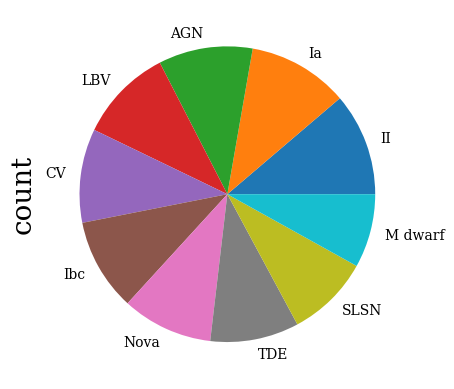

In [14]:
data_balanced['Class'].value_counts().plot.pie()
data_balanced['Class'].value_counts()

In [15]:
indx_type_to_consider_balanced = np.where(
	np.array([(data_balanced['Class'] == source) for source in sources_to_consider]).any(axis=0)
)

print(f"{len(sources_to_consider)} sources to consider: {len(indx_type_to_consider_balanced[0])}")
data_balanced = data_balanced.iloc[indx_type_to_consider_balanced[0]]

logtxt += f"Balanced: {len(sources_to_consider)} sources to consider: {len(indx_type_to_consider_balanced[0])}\n"
logtxt += "\n"

10 sources to consider: 282753


- Split features/target, handle missing values

In [16]:
X_balanced = data_balanced.drop(columns=['Sample_ID', 'Class', 'uid'])
y_balanced = data_balanced['Class']
X_balanced.fillna(-99, inplace=True)

In [17]:
y_balanced.unique()

array(['Ia', 'Ibc', 'II', 'SLSN', 'CV', 'LBV', 'AGN', 'M dwarf', 'Nova',
       'TDE'], dtype=object)

- Split into train/test using GroupShuffleSplit by uid

In [18]:
gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
train_idx_balanced, test_idx_balanced = next(gss.split(X_balanced, y_balanced, groups=data_balanced['uid']))
X_train_balanced, X_test_balanced = X_balanced.iloc[train_idx_balanced], X_balanced.iloc[test_idx_balanced]
y_train_balanced, y_test_balanced = y_balanced.iloc[train_idx_balanced], y_balanced.iloc[test_idx_balanced]

- Label encode class for ML

In [ ]:
label_encoder = LabelEncoder()
y_train_balanced_encoded = label_encoder.fit_transform(y_train_balanced)
y_test_balanced_encoded = label_encoder.transform(y_test_balanced)
class_names = np.array([str(c) for c in label_encoder.inverse_transform(np.arange(len(label_encoder.classes_)))])
print("Balanced: Class mapping:", class_names)

Balanced: Class mapping: ['AGN' 'CV' 'II' 'Ia' 'Ibc' 'LBV' 'M dwarf' 'Nova' 'SLSN' 'TDE']


In [20]:
# class_names = np.array([str(c) for c in label_encoder.inverse_transform(np.arange(len(label_encoder.classes_)))])
# class_names
# for key in data_balanced.keys():
#     print(f"""'{key}': float,""")

# Tests

1. Original Data (no augmentation)
2. Augmented Data
3. Undersampling of the majority class
4. Oversampling of the minority class


In [21]:
classifier_type = 'normal_class_classifier'
model_param_config = model_config[classifier_type][device_type]
params = model_param_config['params_lightgbm']
params['num_class'] = len(label_encoder.classes_)
params

{'objective': 'multiclass',
 'force_col_wise': True,
 'early_stopping_rounds': 30,
 'device_type': 'cpu',
 'n_jobs': -1,
 'num_class': 10}

In [22]:
metrics_list = []
cm_dict = {}
eval_metrics_list = ["f1_macro", "f1_weighted", "precision_macro", "recall_macro", "accuracy"]

## Balanced Samples

### All Classes (Base)

In [ ]:
lgbm_exp_balanced = LightGBMExperiment(
    X_train_balanced, X_test_balanced, y_train_balanced_encoded, y_test_balanced_encoded,
    label_encoder, params, eval_metrics_list, path_save, do_cv=False
)

model_balanced, metrics_balanced = lgbm_exp_balanced.run()

lgbm_exp_balanced.plot_confusion_matrix()
cm_balanced, labels_balanced = lgbm_exp_balanced.get_confusion_matrix()
cm_dict['balanced'] = cm_balanced

metrics_balanced['test_name'] = 'balanced'
metrics_list.append(metrics_balanced)

[LightGBM] [Info] Total Bins 456450
[LightGBM] [Info] Number of data points in the train set: 227957, number of used features: 1790
[LightGBM] [Info] Start training from score -2.306704
[LightGBM] [Info] Start training from score -2.313245
[LightGBM] [Info] Start training from score -2.203822
[LightGBM] [Info] Start training from score -2.202908
[LightGBM] [Info] Start training from score -2.308026
[LightGBM] [Info] Start training from score -2.296231
[LightGBM] [Info] Start training from score -2.336253
[LightGBM] [Info] Start training from score -2.333444
[LightGBM] [Info] Start training from score -2.416469
[LightGBM] [Info] Start training from score -2.326590
Training until validation scores don't improve for 30 rounds


### Merging stellar-eruption object
- CV, LBV, Nova, M dwarf

In [40]:
class_dict = {}

for classname, classidx in zip(class_names, range(len(class_names))):
    class_dict[classname] = classidx

class_dict

{'AGN': 0,
 'CV': 1,
 'II': 2,
 'Ia': 3,
 'Ibc': 4,
 'LBV': 5,
 'M dwarf': 6,
 'Nova': 7,
 'SLSN': 8,
 'TDE': 9}

- CV(1), LBV(5), M dwarf(6), Nova(7) → S(tellar) E(ruption) (10)

In [ ]:
params_group = params.copy()

y_train_group = y_train_balanced.copy()
y_test_group = y_test_balanced.copy()

for i in range(len(y_train_group)):
    if y_train_group[i] in ["CV", "LBV", "M dwarf", "Nova"]:
        y_train_group[i] = "SE"

for i in range(len(y_test_group)):
    if y_test_group[i] in ["CV", "LBV", "M dwarf", "Nova"]:
        y_test_group[i] = "SE"

label_encoder = LabelEncoder()
y_train_group_encoded = label_encoder.fit_transform(y_train_group)
y_test_group_encoded = label_encoder.transform(y_test_group)

params_group['num_class'] = len(label_encoder.classes_)

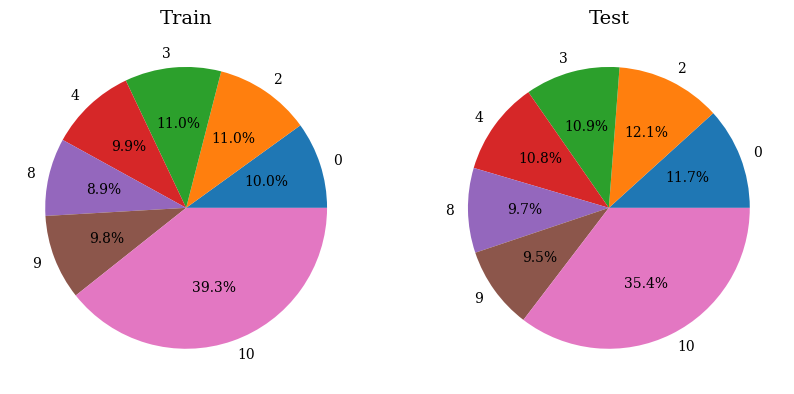

In [ ]:
fig = plt.figure(figsize=(10, 5))
plt.subplot(121)
_, counts_train = np.unique(y_train_group_encoded, return_counts=True)
_ = plt.pie(counts_train, labels=np.unique(y_train_group_encoded), autopct='%1.1f%%')
plt.title('Train')
plt.subplot(122)
_, counts_test = np.unique(y_test_group_encoded, return_counts=True)
_ = plt.pie(counts_test, labels=np.unique(y_test_group_encoded), autopct='%1.1f%%')
plt.title('Test')
plt.show()

In [ ]:
lgbm_exp_group = LightGBMExperiment(
    X_train_balanced, X_test_balanced, y_train_group_encoded, y_test_group_encoded,
    label_encoder, params_group,
    eval_metrics_list, path_save, do_cv=False, groups=data_balanced['uid']
)

model_group, metrics_group = lgbm_exp_group.run()

lgbm_exp_group.plot_confusion_matrix()
cm_group, labels_group = lgbm_exp_group.get_confusion_matrix()
cm_dict['group'] = cm_group

metrics_group['test_name'] = 'group'
metrics_list.append(metrics_group)

[LightGBM] [Fatal] Label must be in [0, 7), but found 8 in label


LightGBMError: Label must be in [0, 7), but found 8 in label

# Result

In [40]:
metrics_df = pd.concat(metrics_list, ignore_index=True)

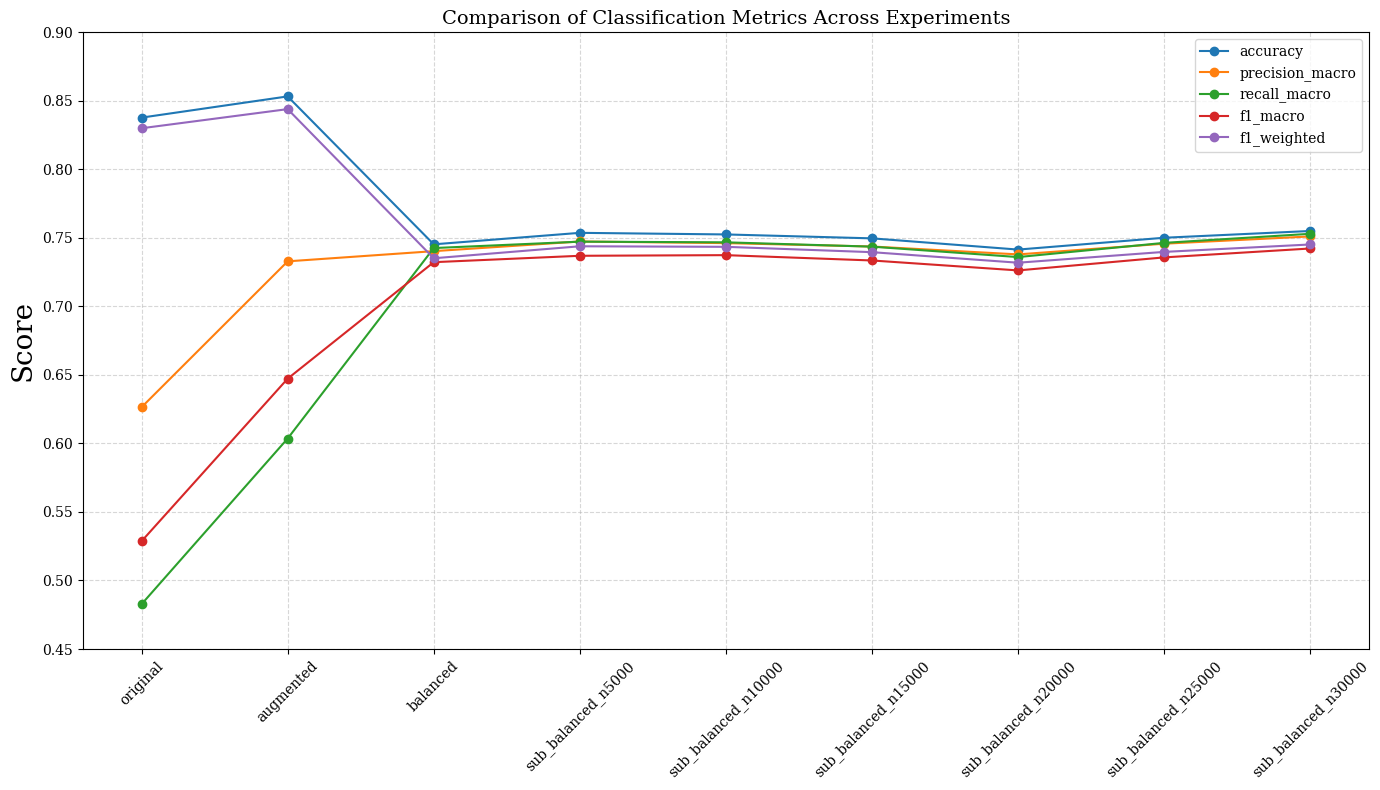

In [41]:
# Plot metrics comparison
metrics_to_plot = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_weighted"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

plt.figure(figsize=(14, 8))

for i, metric in enumerate(metrics_to_plot):
    plt.plot(metrics_df["test_name"], metrics_df[metric], marker='o', label=metric, color=colors[i])

plt.xticks(rotation=45)
plt.ylabel("Score")
plt.ylim(0.45, 0.9)
plt.title("Comparison of Classification Metrics Across Experiments")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

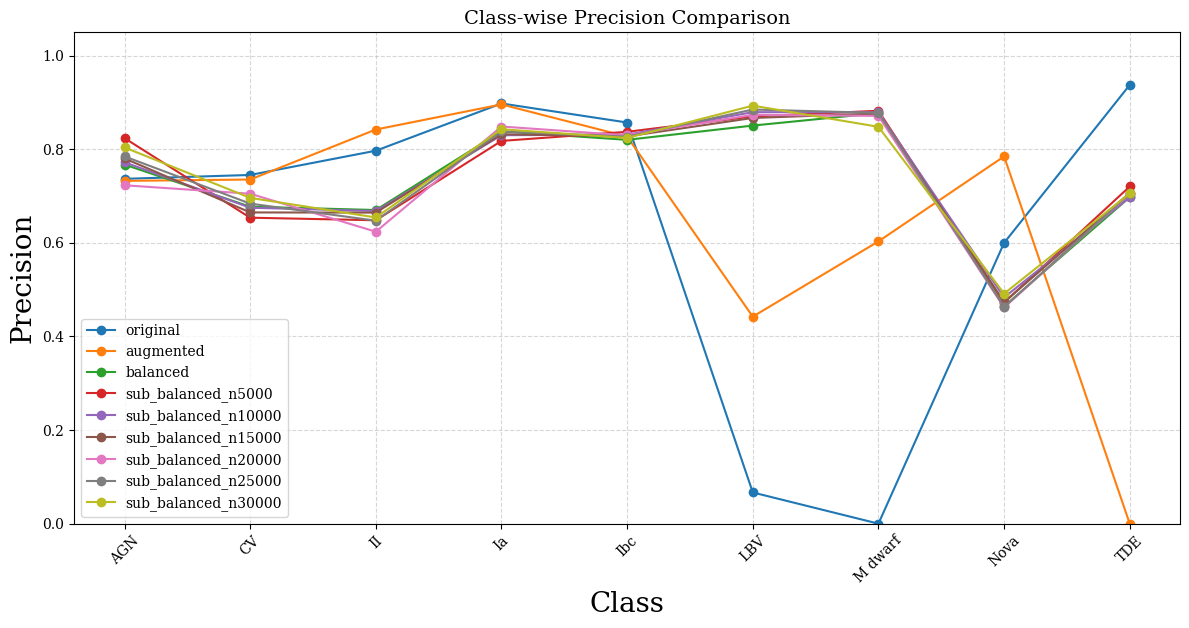

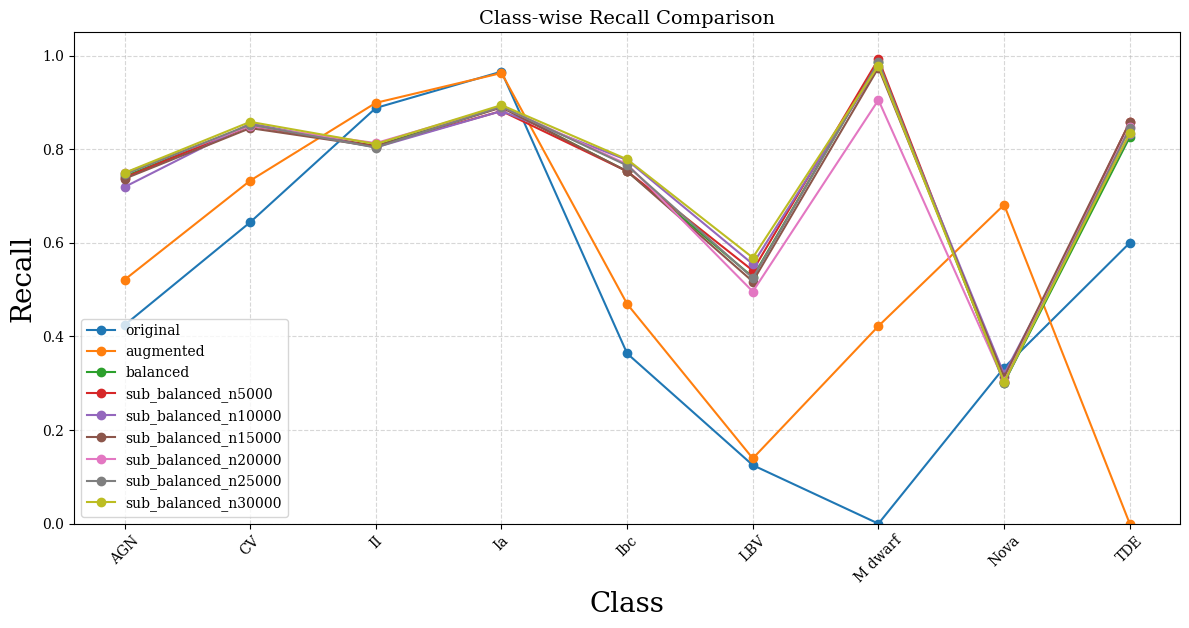

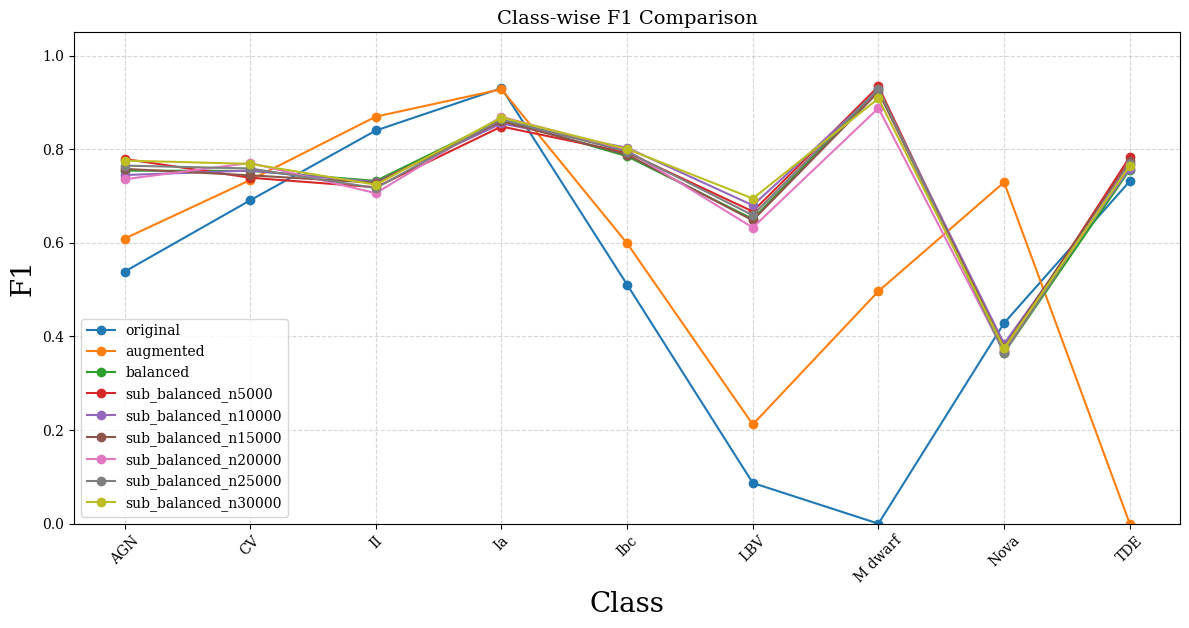

In [43]:
from sklearn.metrics import precision_recall_fscore_support

# 클래스 라벨 (예시)
class_names = ['AGN', 'CV', 'II', 'Ia', 'Ibc', 'LBV', 'M dwarf', 'Nova', 'TDE']

# 클래스별 지표 저장용
records = []

for name, cm in cm_dict.items():
    y_true = []
    y_pred = []
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            y_true.extend([i] * cm[i, j])
            y_pred.extend([j] * cm[i, j])
    # 각 클래스별 precision, recall, f1 계산
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=range(len(class_names)), zero_division=0
    )
    for i, cls in enumerate(class_names):
        records.append({
            'experiment': name,
            'class': cls,
            'precision': precision[i],
            'recall': recall[i],
            'f1': f1[i]
        })

# DataFrame으로 변환
df_metrics = pd.DataFrame(records)

# === 시각화 ===
metrics = ['precision', 'recall', 'f1']

for metric in metrics:
    plt.figure(figsize=(12, 6))
    for name in cm_dict.keys():
        subset = df_metrics[df_metrics['experiment'] == name]
        plt.plot(subset['class'], subset[metric], marker='o', label=name)
    
    plt.title(f'Class-wise {metric.title()} Comparison')
    plt.ylabel(metric.title())
    plt.xlabel('Class')
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.show()

In [37]:
# 모든 결과를 하나의 csv로 저장
metrics_all = pd.concat(metrics_list, ignore_index=True)
metrics_all.to_csv(os.path.join(path_save, "metrics_summary.csv"), index=False)
print("Experiment complete. Results saved in:", path_save)

Experiment complete. Results saved in: /Users/paek/Research/7DT/SED-Classifier/notebook/../model/different_sampling
